In [2]:
from rocketpy import Environment,Rocket,SolidMotor,Flight
import datetime

In [3]:
#definimos las condiciones atmosféricas y la fecha de lanzamiento

env=Environment(latitude=37.08, longitude=-6.703611111111111, elevation=34)
env.max_expected_height=3000
mañana=datetime.date.today() + datetime.timedelta(days=1)
fecha=(mañana.year, mañana.month,mañana.day,1)
env.set_date(fecha, timezone="CET")
env.set_atmospheric_model(type="Windy", file="ECMWF")



In [4]:
#definimos el motor, el motor de skybreaker es un motor con propelente Sólido, luego hemos importado esta clase
rocketengine=SolidMotor(
    thrust_source='/Users/aitorpg/Documents/FARADAY/RocketPy/M1128_95.eng',
    dry_mass= 3.6599000000000004,
    dry_inertia=(0.132345,0.132345,0.0067256454),# en el txt datos_skybreaker, pone cdg luego asumo que se refiere a al centro de masas sin el propellente (dry cdg)
    nozzle_radius=0.0219252, 
    grain_number=1, 
    grain_density=1450.08, 
    grain_outer_radius=0.0415,
    grain_initial_inner_radius=0.01, 
    grain_initial_height=0.4184, 
    grain_separation=0.0,
    grains_center_of_mass_position=0.330783,
    center_of_dry_mass_position= 0.2755753,
    nozzle_position=0, #se mide respecto de la tobera
    throat_radius=0.01025,
    reshape_thrust_curve=False, #defalut
    interpolation_method='linear', #default
    coordinate_system_orientation='nozzle_to_combustion_chamber')  #he deducido esta orientación porque la posición del centro de masas es positiva y se mide respecto de la tobera (origen de coordenadas del systema de coordenadas del motor)


                    

In [5]:
skybreaker=Rocket(
    radius=0.057, 
    mass=10.376,
    inertia=(2.94266, 2.94266,0.0033674953),
    power_off_drag='/Users/aitorpg/Documents/FARADAY/RocketPy/power_off_drag.csv',
    power_on_drag='/Users/aitorpg/Documents/FARADAY/RocketPy/power_on_drag.csv',
    center_of_mass_without_motor=1.06588, #la punta de la ojiva es el origen de coordenadas
    coordinate_system_orientation='nose_to_tail'
    )

length_skybreaker=1.9838
skybreaker.add_motor(
    rocketengine, 
    position=length_skybreaker)
#por definición del sistema de coordenadas, la posición del eje de coordenadas del motor respecto del eje de coordenadas del cohete es la lognitud del cohete


skybreaker.add_trapezoidal_fins(
    n=4,
    root_chord=0.225,
    tip_chord=0.143,
    span=0.135, 
    position=1.6136300000000001,
    sweep_length=0.0819)


skybreaker.add_nose(
    length=0.327, 
    kind='Von Karman', 
    position=0)


skybreaker.add_parachute(
    name="main", 
    cd_s=3.81207918, 
    trigger=450,
    lag=0.682116)


skybreaker.add_parachute(
    name="drogue", 
    cd_s=0.14909999999999998, 
    trigger='apogee',
    lag=0.162211)



<Parachute drogue (cd_s = 0.1491 m2, trigger = apogee)>

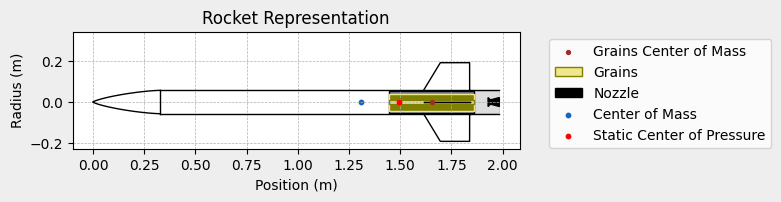

In [6]:
skybreaker.draw()

In [7]:
skybreaker_flight=Flight(
    rocket=skybreaker,
    environment=env, 
    rail_length=12,
    inclination=84,
    heading=300)



In [8]:
#empuje maximo
print(rocketengine.max_thrust)


994.8865356


In [9]:
#impulso total
print(rocketengine.total_impulse)

5032.54463688246


In [10]:
#burn_time
print(rocketengine.burn_duration)


6.6992


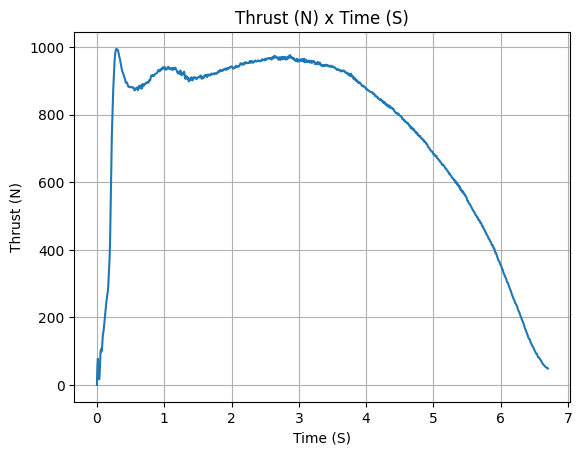

In [11]:
#curva de empuje en función del tiempo
rocketengine.plots.thrust()

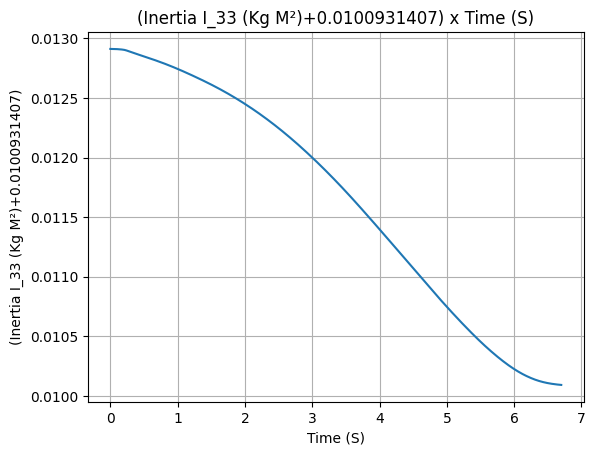

In [12]:
#inercia longitudinal en función del tiempo
skybreaker.I_33()

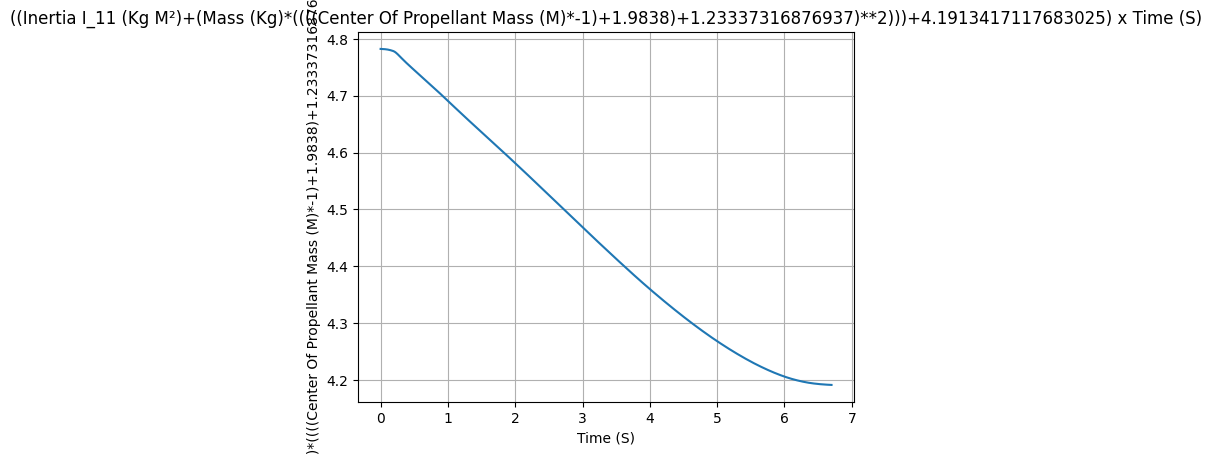

In [13]:
#inercia radial en función del tiempo
skybreaker.I_11()

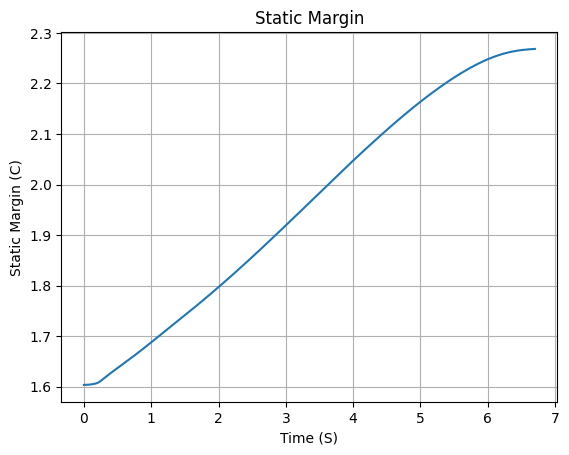

In [14]:
#margen estático en funicón del tiempo
skybreaker.plots.static_margin()

In [15]:
#posición inicial del centro de gravedad
float(skybreaker.center_of_mass(0))

1.3091307127981286

In [16]:
#posicion inicial del centro de presiones
float(skybreaker.cp_position(0))

1.491944720500211

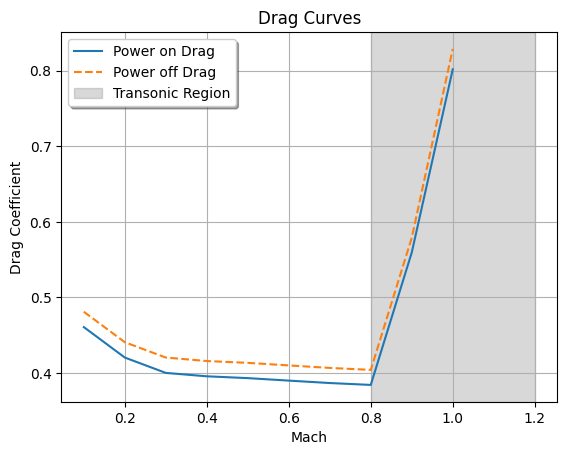

In [17]:
#coeficiente de drag en función de mach
skybreaker.plots.drag_curves()


In [18]:
#masa inicial total con el propelente y el motor
print(skybreaker.total_mass(0))

17.12798407489959


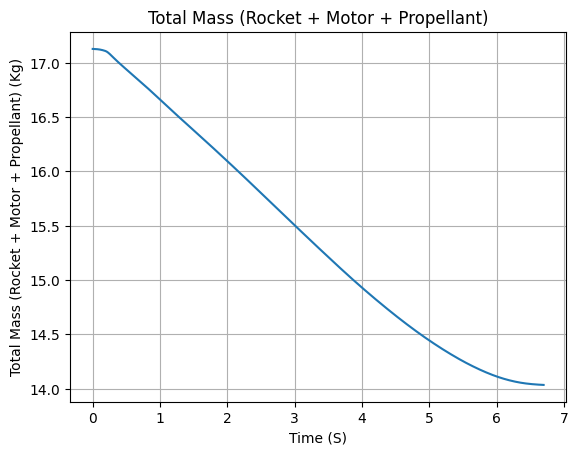

14.0359


In [19]:
#masa en función del tiempo
skybreaker.plots.total_mass()
print(skybreaker.dry_mass)

In [20]:
skybreaker_flight.prints.apogee_conditions()


Apogee State

Apogee Time: 25.207 s
Apogee Altitude: 2839.385 m (ASL) | 2773.385 m (AGL)
Apogee Freestream Speed: 46.751 m/s
Apogee X position: -844.379 m
Apogee Y position: 414.912 m
Apogee latitude: 37.0837314°
Apogee longitude: -6.7131308°


In [62]:
print('el viento en el eje y es', env.wind_velocity_y(34))
print('el viento en el eje x es', env.wind_velocity_x(34))


el viento en el eje y es -0.89
el viento en el eje x es 1.96


In [41]:
env.wind_speed(2000)

np.float64(12.397127705817354)

In [42]:
#maximizing apogee
skybreaker_flight_max_apogee=Flight(
    rocket=skybreaker,
    environment=env, 
    rail_length=12,
    inclination=86,
    heading=145)

skybreaker_flight_max_apogee.prints.apogee_conditions()


Apogee State

Apogee Time: 25.710 s
Apogee Altitude: 2944.875 m (ASL) | 2878.875 m (AGL)
Apogee Freestream Speed: 4.746 m/s
Apogee X position: 17.390 m
Apogee Y position: -320.563 m
Apogee latitude: 37.0771168°
Apogee longitude: -6.7034151°


In [43]:
skybreaker_flight_max_apogee.prints.out_of_rail_conditions()


Rail Departure State

Rail Departure Time: 0.933 s
Rail Departure Velocity: 32.395 m/s
Rail Departure Stability Margin: 1.682 c
Rail Departure Angle of Attack: 3.810°
Rail Departure Thrust-Weight Ratio: 5.667
Rail Departure Reynolds Number: 2.584e+05


In [44]:
#tiempo hasta el apogeo
skybreaker_flight_max_apogee.prints.apogee_conditions()


Apogee State

Apogee Time: 25.710 s
Apogee Altitude: 2944.875 m (ASL) | 2878.875 m (AGL)
Apogee Freestream Speed: 4.746 m/s
Apogee X position: 17.390 m
Apogee Y position: -320.563 m
Apogee latitude: 37.0771168°
Apogee longitude: -6.7034151°


In [45]:
# velocidad maxima
float(skybreaker_flight_max_apogee.max_speed)

235.95493994820723

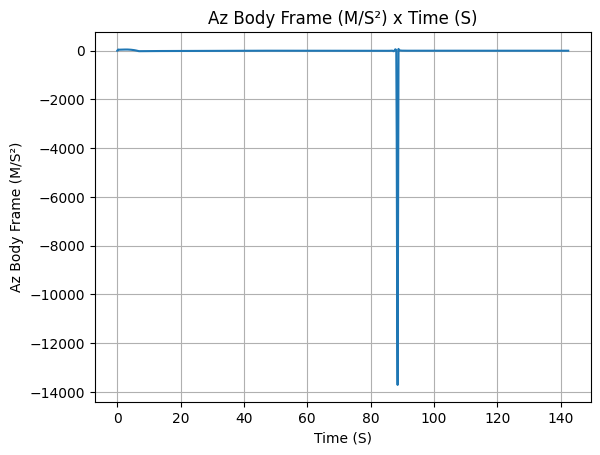

In [46]:
#aceleración longitudinal (z) en función del tiempo
skybreaker_flight_max_apogee.az_body_frame()



In [47]:

resultado=skybreaker_flight_max_apogee.az_body_frame
float(resultado.max)

133.36690776657255

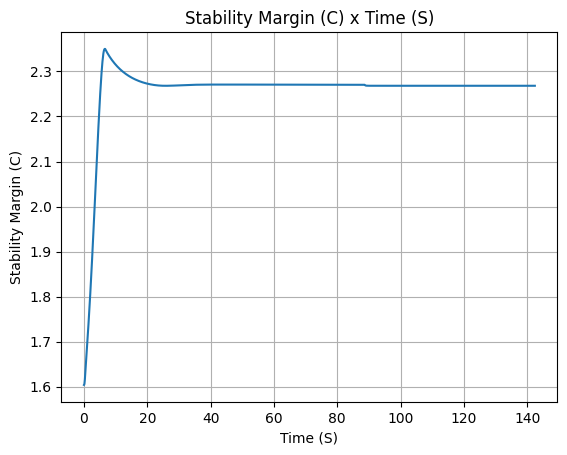

In [48]:
#margen de estabilidad en función del tiempo
skybreaker_flight_max_apogee.stability_margin()

In [49]:
#margen de estabilidad a la salida del rail
float(skybreaker_flight_max_apogee.stability_margin(0.932))

1.6821480552051193

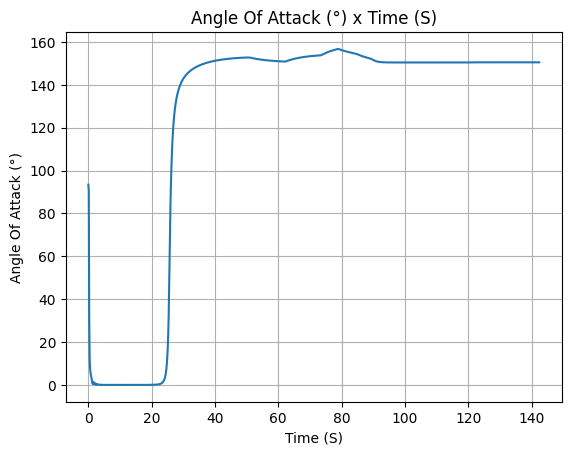

In [50]:
skybreaker_flight_max_apogee.angle_of_attack()

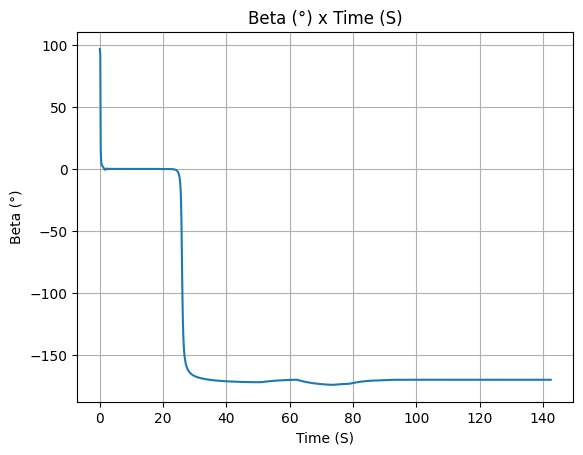

In [51]:
#angulo de derrape
skybreaker_flight_max_apogee.angle_of_sideslip()

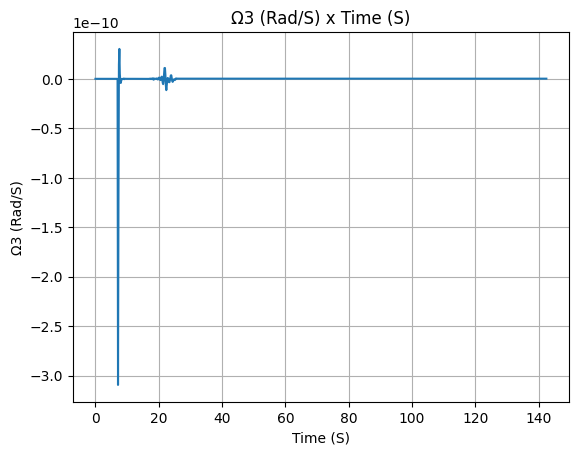

In [52]:
# velocidad de alabeo (velocidad angular en del angulo de alabeo)

skybreaker_flight_max_apogee.w3() 

In [53]:
#coordenadas (x,y) del apogeo 
skybreaker_flight_max_apogee.prints.apogee_conditions()


Apogee State

Apogee Time: 25.710 s
Apogee Altitude: 2944.875 m (ASL) | 2878.875 m (AGL)
Apogee Freestream Speed: 4.746 m/s
Apogee X position: 17.390 m
Apogee Y position: -320.563 m
Apogee latitude: 37.0771168°
Apogee longitude: -6.7034151°


In [54]:
#cordenadas x e y del apogeo, también se podría haber obtenido con el método impact_conditions de la clase _FlightPrints que se accede mediante el atributo prints de el objeto flight
print('las cordenada x del apogeo es', skybreaker_flight_max_apogee.apogee_x)
print('la cordenada y del apoogeo es', skybreaker_flight_max_apogee.apogee_y)


las cordenada x del apogeo es 17.38979409030923
la cordenada y del apoogeo es -320.5633778881779


In [55]:
#cordenadas x e y del impacto, también se podría haber obtenido con el método apogee_conditions de la clase _FlightPrints que se accede mediante el atributo prints de el objeto flight
print('las cordenada x del impacto es', skybreaker_flight_max_apogee.x_impact)
print('la cordenada y del impacto es', skybreaker_flight_max_apogee.y_impact)

las cordenada x del impacto es 280.6856888687513
la cordenada y del impacto es -1105.9629305891017


In [56]:
#downrange
import math
downrange=math.sqrt((skybreaker_flight_max_apogee.x_impact**2)+(skybreaker_flight_max_apogee.y_impact**2))
print(f'El downrange es {downrange}')

El downrange es 1141.025179289642


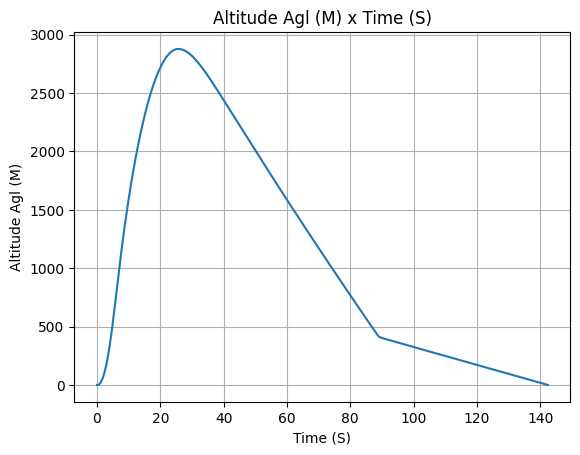

In [57]:
#altitud en función del tiempo
skybreaker_flight_max_apogee.altitude()

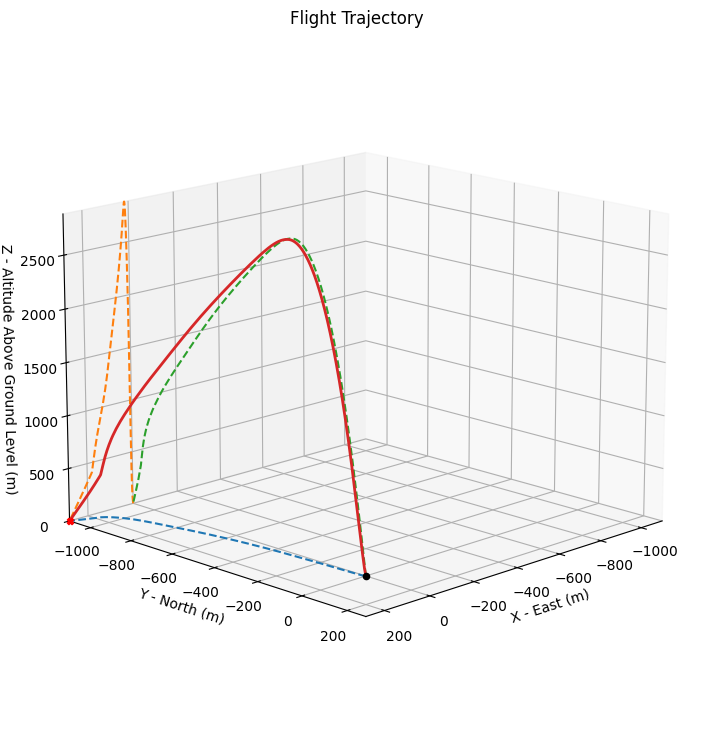

In [58]:
skybreaker_flight_max_apogee.plots.trajectory_3d()